# CardioIA · Fase 2 · Parte 2 — Classificador de risco com TF-IDF

Objetivo: classificar frases de sintomas como **"alto risco"** ou **"baixo risco"**, simulando a
triagem clínica automatizada.

Etapas: (1) carregar o `dataset.csv` · (2) TF-IDF · (3) treinar modelos simples ·
(4) avaliar acurácia e erros · (5) olhar para vieses e limitações.

> Projeto acadêmico com dados **simulados**. Não deve ser usado para decisões clínicas reais.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

try:  # evita erro de acentos no console do Windows
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass

try:  # script .py
    BASE_DIR = Path(__file__).resolve().parent
except NameError:  # notebook
    BASE_DIR = Path.cwd()

SEED = 42


def mostrar(fig, nome_arquivo):
    """Salva a figura; exibe apenas se estiver rodando em notebook."""
    fig.savefig(BASE_DIR / nome_arquivo, dpi=120, bbox_inches="tight")
    if "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close(fig)

## 1. Carregando o dataset
O arquivo `dataset.csv` tem duas colunas: `frase` e `situacao` (o rótulo de risco).

In [2]:
df = pd.read_csv(BASE_DIR / "dataset.csv", encoding="utf-8")
assert {"frase", "situacao"} <= set(df.columns), "dataset.csv precisa das colunas frase e situacao"
print(f"{len(df)} frases")
print(df["situacao"].value_counts())
print(df.sample(6, random_state=SEED).to_string(index=False))

120 frases
situacao
alto risco     60
baixo risco    60
Name: count, dtype: int64
                                                      frase    situacao
confusão mental e pressão muito baixa com pele fria e suada  alto risco
       não consigo caminhar porque a falta de ar é imediata  alto risco
               falta de ar intensa mesmo sentado em repouso  alto risco
dor no peito intensa e dificuldade para respirar desde cedo  alto risco
           palpitações intensas com suor frio e falta de ar  alto risco
                     nariz entupido e espirros há dois dias baixo risco


O dataset é **balanceado** (60 frases de cada classe), então a acurácia é uma métrica razoável aqui.
Separamos 75% para treino e 25% para teste, **estratificando** pelo rótulo.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df["frase"], df["situacao"], test_size=0.25, stratify=df["situacao"], random_state=SEED
)
print(f"treino: {len(X_train)} frases | teste: {len(X_test)} frases")

treino: 90 frases | teste: 30 frases


## 2. TF-IDF: de texto para vetores numéricos
O **TF-IDF** dá a cada termo um peso: alto quando aparece muito na frase (TF) e é raro no conjunto de
frases (IDF). Usamos unigramas e bigramas (ex.: "dor peito") e remoção de acentos. Mantemos palavras
como *não* e *sem* fora da lista de stopwords, porque mudam o sentido clínico.

In [4]:
STOPWORDS_PT = [
    "a", "o", "as", "os", "de", "da", "do", "das", "dos", "em", "no", "na", "nos", "nas",
    "um", "uma", "e", "que", "com", "para", "por", "ao", "aos", "me", "meu", "minha", "se",
]


def novo_vetorizador():
    return TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        stop_words=STOPWORDS_PT,
        sublinear_tf=True,
    )


# Demonstração: matriz TF-IDF do conjunto de treino
vetorizador_demo = novo_vetorizador()
X_demo = vetorizador_demo.fit_transform(X_train)
print(f"Matriz TF-IDF: {X_demo.shape[0]} frases x {X_demo.shape[1]} termos (esparsa)")

primeira = X_train.iloc[0]
linha = X_demo[0].toarray().ravel()
termos = vetorizador_demo.get_feature_names_out()
pesos = pd.Series(linha, index=termos)
print(f'\nFrase: "{primeira}"')
print("Maiores pesos TF-IDF:")
print(pesos[pesos > 0].sort_values(ascending=False).head(8).round(3).to_string())

Matriz TF-IDF: 90 frases x 661 termos (esparsa)

Frase: "dor muscular nas pernas depois de caminhar muito"
Maiores pesos TF-IDF:
caminhar muito     0.347
dor muscular       0.347
depois caminhar    0.347
pernas depois      0.347
muscular           0.347
muscular pernas    0.347
caminhar           0.318
pernas             0.281


## 3. Treinando classificadores simples
Comparamos **Regressão Logística** e **Árvore de Decisão**. Cada modelo fica em um `Pipeline`
(TF-IDF → classificador): o vetorizador só "enxerga" os dados de treino, evitando vazamento de dados.

In [5]:
modelos = {
    "Regressão Logística": Pipeline([
        ("tfidf", novo_vetorizador()),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "Árvore de Decisão": Pipeline([
        ("tfidf", novo_vetorizador()),
        ("clf", DecisionTreeClassifier(max_depth=6, random_state=SEED)),
    ]),
}

resultados = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for nome, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    acc_teste = accuracy_score(y_test, pipe.predict(X_test))
    acc_cv = cross_val_score(pipe, df["frase"], df["situacao"], cv=cv, scoring="accuracy")
    resultados.append({
        "modelo": nome,
        "acurácia (teste 25%)": round(acc_teste, 3),
        "acurácia média (CV 5-fold)": round(acc_cv.mean(), 3),
        "desvio (CV)": round(acc_cv.std(), 3),
    })
print(pd.DataFrame(resultados).to_string(index=False))

             modelo  acurácia (teste 25%)  acurácia média (CV 5-fold)  desvio (CV)
Regressão Logística                 0.967                       0.950        0.031
  Árvore de Decisão                 0.967                       0.883        0.076


Com apenas ~30 frases no teste, cada erro custa ~3,3 pontos percentuais; por isso a validação
cruzada (5-fold) dá uma estimativa mais estável do que o split único.

## 4. Avaliação detalhada (Regressão Logística)
Escolhemos a Regressão Logística como modelo principal por ser **interpretável**: dá para ver
quais termos empurram a previsão para cada classe.

Acurácia no teste: 96.67%

              precision    recall  f1-score   support

  alto risco      1.000     0.933     0.966        15
 baixo risco      0.938     1.000     0.968        15

    accuracy                          0.967        30
   macro avg      0.969     0.967     0.967        30
weighted avg      0.969     0.967     0.967        30



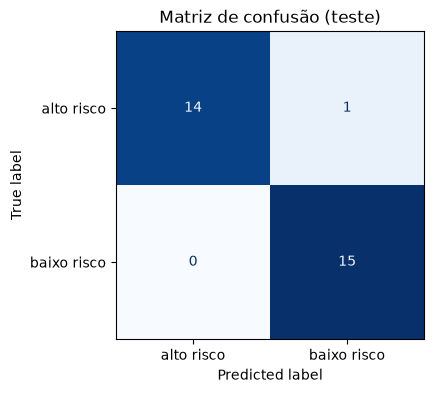

In [6]:
modelo = modelos["Regressão Logística"]
y_pred = modelo.predict(X_test)
print(f"Acurácia no teste: {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred, labels=modelo.classes_), display_labels=modelo.classes_
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão (teste)")
mostrar(fig, "matriz_confusao.png")

**Como ler:** em triagem, o erro mais grave é o **falso negativo** (um caso de *alto risco*
classificado como *baixo risco*). Olhe o *recall* da classe "alto risco" no relatório acima.

In [7]:
# Frases erradas no teste
probas = modelo.predict_proba(X_test)
idx_alto = list(modelo.classes_).index("alto risco")
erros = pd.DataFrame({
    "frase": X_test.values,
    "real": y_test.values,
    "previsto": y_pred,
    "prob_alto_risco": probas[:, idx_alto].round(2),
})
erros = erros[erros["real"] != erros["previsto"]]
print(f"{len(erros)} erro(s) no conjunto de teste")
if len(erros):
    print(erros.to_string(index=False))

1 erro(s) no conjunto de teste
                                                     frase       real    previsto  prob_alto_risco
perdi a consciência por alguns segundos enquanto caminhava alto risco baixo risco             0.47


## 5. O que o modelo aprendeu? (interpretabilidade)

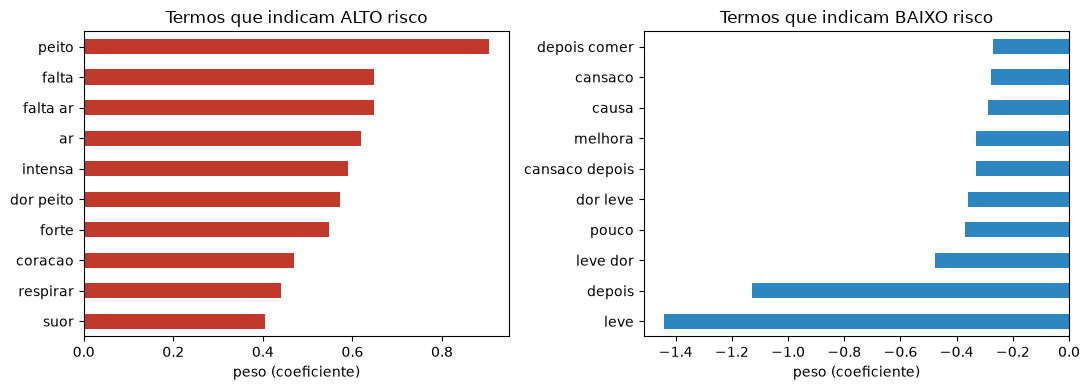

In [8]:
tfidf = modelo.named_steps["tfidf"]
clf = modelo.named_steps["clf"]
nomes = tfidf.get_feature_names_out()
# coeficientes positivos empurram para classes_[1]; ajustamos para que positivo = alto risco
pesos_alto = clf.coef_[0] if idx_alto == 1 else -clf.coef_[0]
ordem = np.argsort(pesos_alto)

top_alto = pd.Series(pesos_alto[ordem[::-1][:10]], index=nomes[ordem[::-1][:10]])
top_baixo = pd.Series(pesos_alto[ordem[:10]], index=nomes[ordem[:10]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
top_alto[::-1].plot.barh(ax=axes[0], color="#c0392b")
axes[0].set_title("Termos que indicam ALTO risco")
top_baixo.plot.barh(ax=axes[1], color="#2e86c1")
axes[1].set_title("Termos que indicam BAIXO risco")
for ax in axes:
    ax.set_xlabel("peso (coeficiente)")
fig.tight_layout()
mostrar(fig, "termos_mais_influentes.png")

## 6. Testando frases novas e procurando distorções
Aqui sondamos o modelo com frases que **não estão no dataset**, incluindo casos difíceis:
negação, termos benignos em contexto grave e variação de gênero na descrição do paciente.

In [9]:
def prob_alto_risco(frases):
    return modelo.predict_proba(frases)[:, idx_alto]


def sondar(titulo, frases):
    p = prob_alto_risco(frases)
    print(f"--- {titulo} ---")
    for frase, prob in zip(frases, p):
        rotulo = "alto risco" if prob >= 0.5 else "baixo risco"
        print(f"{prob:5.0%}  {rotulo:<11}  {frase}")
    print()


sondar("Casos claros", [
    "estou com dor no peito e falta de ar",
    "tive um leve incômodo nas costas depois de treinar",
])
sondar("Negação (o modelo não entende a ordem/negação das palavras)", [
    "não tenho dor no peito",
    "não tenho dor no peito nem falta de ar",
    "sem falta de ar e sem dor no peito apenas cansaço leve",
])
sondar("Mesma queixa, gênero diferente (o modelo deveria dar probabilidades parecidas)", [
    "homem de 55 anos com dor no peito",
    "mulher de 55 anos com dor no peito",
])
sondar("Apresentação atípica (comum em mulheres e idosos)", [
    "sinto náusea e um cansaço fora do normal há dias",
    "sinto mal estar estranho e dor nas costas com suor frio",
])

--- Casos claros ---
  77%  alto risco   estou com dor no peito e falta de ar
  30%  baixo risco  tive um leve incômodo nas costas depois de treinar

--- Negação (o modelo não entende a ordem/negação das palavras) ---
  70%  alto risco   não tenho dor no peito
  68%  alto risco   não tenho dor no peito nem falta de ar
  58%  alto risco   sem falta de ar e sem dor no peito apenas cansaço leve

--- Mesma queixa, gênero diferente (o modelo deveria dar probabilidades parecidas) ---
  72%  alto risco   homem de 55 anos com dor no peito
  72%  alto risco   mulher de 55 anos com dor no peito

--- Apresentação atípica (comum em mulheres e idosos) ---
  52%  alto risco   sinto náusea e um cansaço fora do normal há dias
  59%  alto risco   sinto mal estar estranho e dor nas costas com suor frio



## 7. Conclusões, vieses e limitações

- **Acurácia alta não significa um bom sistema de triagem.** O dataset é pequeno (120 frases),
  simulado e escrito com vocabulário parecido nas duas classes, o que tende a deixar o resultado
  otimista.
- **O modelo aprende palavras, não medicina.** Termos como *intensa*, *forte*, *dor no peito* e
  *falta de ar* puxam para "alto risco"; *leve*, *pequeno* e *depois de* puxam para "baixo risco".
  Isso já é um viés de vocabulário: um paciente que minimiza os sintomas ("só um desconforto")
  pode ser subclassificado.
- **Negação não é tratada.** TF-IDF + bag-of-words ignora a lógica de "não tenho dor no peito".
- **Viés de representatividade.** O dataset não traz variação de gênero, idade ou apresentação atípica
  (comum em mulheres com infarto). Em um sistema real, isso pode gerar subdiagnóstico de grupos
  sub-representados — daí a importância da **governança de dados**.
- **Falso negativo é o erro mais caro** na triagem. Em um produto real, ajustaríamos o limiar de
  decisão para priorizar *recall* de alto risco, mesmo ao custo de mais falsos positivos.
- **Próximos passos:** mais dados reais e anonimizados (com aval ético), tratamento de negação,
  embeddings/modelos de linguagem em português e validação por profissionais de saúde.